In [352]:
import pandas as pd 
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import random
import datetime
import math
import sklearn as sk
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from matplotlib.gridspec import GridSpec

df = pd.read_csv("dataset_mood_smartphone.csv")

In [353]:
df.describe(), df.shape

(         Unnamed: 0          value
 count  3.769120e+05  376710.000000
 mean   4.501273e+05      40.665313
 std    5.411519e+05     273.726007
 min    1.000000e+00  -82798.871000
 25%    9.422875e+04       2.025000
 50%    2.274385e+05       7.029000
 75%    5.160412e+05      29.356000
 max    1.427711e+07   33960.246000,
 (376912, 5))

In [354]:
df.isna().sum()

Unnamed: 0      0
id              0
time            0
variable        0
value         202
dtype: int64

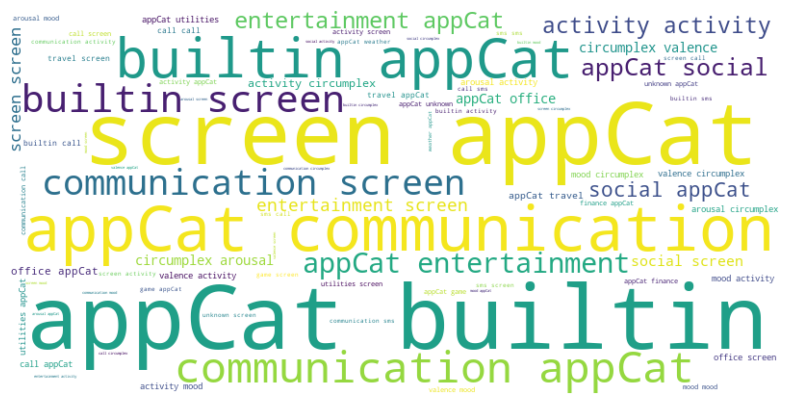

In [355]:
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")
df.dropna(axis=0, inplace=True)

text = " ".join(df["variable"].astype(str))

wc = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [356]:
df

,Unnamed: 0,id,time,variable,value
136621,136622,AS14.02,2014-02-17 07:00:52.197,call,1.000
137398,137399,AS14.06,2014-02-17 07:12:13.631,call,1.000
142363,142364,AS14.14,2014-02-17 07:49:19.635,sms,1.000
142621,142622,AS14.17,2014-02-17 08:57:16.313,sms,1.000
138736,138737,AS14.19,2014-02-17 08:58:58.471,call,1.000
...,...,...,...,...,...
191163,143908,AS14.24,2014-06-08 11:03:34.453,appCat.builtin,44.149
191164,143909,AS14.24,2014-06-08 11:04:20.233,appCat.builtin,16.064
191165,143910,AS14.24,2014-06-08 11:04:36.299,appCat.builtin,10.034
191166,143911,AS14.24,2014-06-08 11:04:46.335,appCat.builtin,8.030


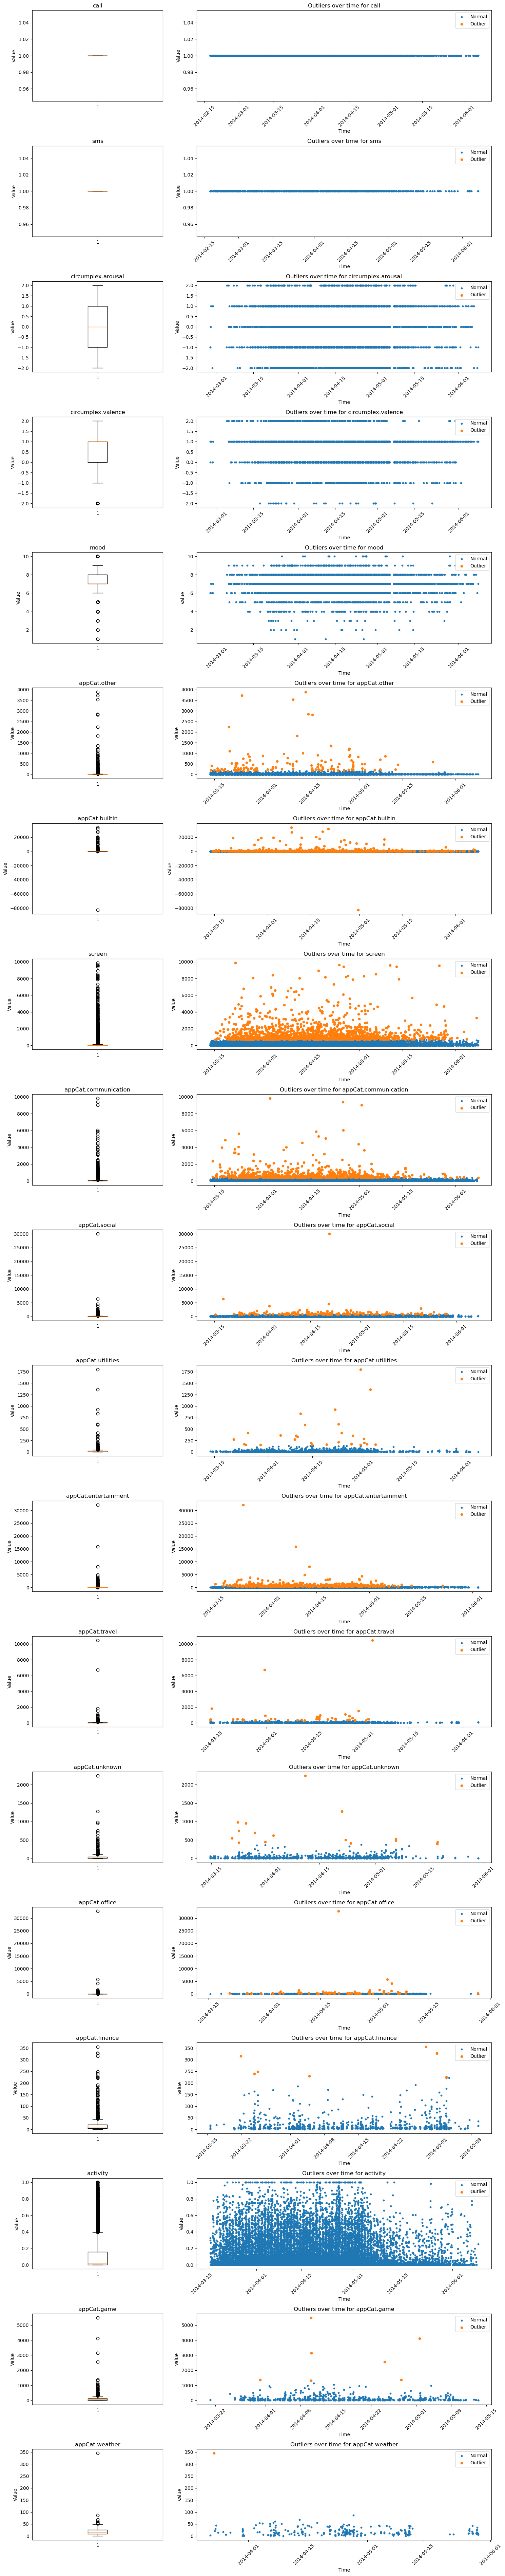

In [357]:
df["time"] = pd.to_datetime(df["time"])
unique_variables = df["variable"].dropna().unique()

nvar = len(unique_variables)
fig = plt.figure(figsize=(15, 4 * nvar))
gs = GridSpec(nvar, 3, figure=fig) 

for i, var in enumerate(unique_variables):
    subset = df[df["variable"] == var].sort_values("time").copy()
    subset = subset.dropna(subset=["time", "value"])

    q1 = subset["value"].quantile(0.05)
    q3 = subset["value"].quantile(0.95)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    subset["is_outlier"] = (subset["value"] < lower) | (subset["value"] > upper)

    # Boxplot takes 1/3
    ax_box = fig.add_subplot(gs[i, 0])
    ax_box.boxplot(subset["value"].dropna(), vert=True)
    ax_box.set_title(var)
    ax_box.set_ylabel("Value")

    # Scatter takes 2/3
    ax_scatter = fig.add_subplot(gs[i, 1:])
    ax_scatter.scatter(
        subset.loc[~subset["is_outlier"], "time"],
        subset.loc[~subset["is_outlier"], "value"],
        s=10,
        label="Normal"
    )
    ax_scatter.scatter(
        subset.loc[subset["is_outlier"], "time"],
        subset.loc[subset["is_outlier"], "value"],
        s=20,
        label="Outlier"
    )
    ax_scatter.set_title(f"Outliers over time for {var}")
    ax_scatter.set_xlabel("Time")
    ax_scatter.set_ylabel("Value")
    ax_scatter.tick_params(axis="x", rotation=45)
    ax_scatter.legend()

plt.tight_layout()
plt.show()

In [358]:
# unique_variables = df["variable"].unique()

# nvar = len(unique_variables)
# ncol = 3
# nrows = math.ceil(nvar/3)

# fig, axs = plt.subplots(nrows, ncol, figsize=(15, 4 * nrows))
# axs = axs.flatten()

# for ax, var in zip(axs, unique_variables):
#     subset = df[df["variable"] == var]["value"]
#     ax.boxplot(subset)
#     ax.set_title(var)
#     ax.set_ylabel("Value")
    
# plt.tight_layout()
# plt.show()

In [359]:
# def plot_outliers_iqr(df, var):
#     subset = df[df["variable"] == var].sort_values("time").copy()
    
#     q1 = subset["value"].quantile(0.05)
#     q3 = subset["value"].quantile(0.95)
#     iqr = q3 - q1
    
#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr
    
#     subset["is_outlier"] = (subset["value"] < lower) | (subset["value"] > upper)
    
#     plt.figure(figsize=(12, 4))
#     plt.scatter(subset.loc[~subset["is_outlier"], "time"],
#                 subset.loc[~subset["is_outlier"], "value"],
#                 s=10,
#                 label="Normal")
    
#     plt.scatter(subset.loc[subset["is_outlier"], "time"],
#                 subset.loc[subset["is_outlier"], "value"],
#                 s=20,
#                 label="Outlier")
    
#     plt.title(f"Outliers for {var}")
#     plt.xlabel("Time")
#     plt.ylabel("Value")
#     plt.xticks(rotation=45)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

# for var in df["variable"].unique():
#     plot_outliers_iqr(df, var)

In [360]:
def obtain_average_and_meadin_time_interval(df, var):
    var_df = df[df["variable"] == var]

    unique_users = var_df["id"].unique()

    for counter in range(10):
        user = unique_users[random.randint(0, len(unique_users) - 1)]
        user_df = var_df[var_df["id"] == user].reset_index() 
        previous_index = 0
        total_time = pd.Timedelta(0)
        for index in range(1, user_df.shape[0]):
            total_time += user_df["time"][index] - user_df["time"][previous_index] 
            previous_index = index

        if counter == 0:
            average = total_time/user_df.shape[0]
        else:
            average = average/(counter + 1) + (total_time/user_df.shape[0])/(counter + 1)

    return average 

for var in unique_variables:
    print(var + " has an average time interval of:  " + str(obtain_average_and_meadin_time_interval(df, var).total_seconds()) + " s")

call has an average time interval of:  8258.816955 s
sms has an average time interval of:  14348.450102 s
circumplex.arousal has an average time interval of:  2211.121402 s
circumplex.valence has an average time interval of:  2190.032546 s
mood has an average time interval of:  2243.275147 s
appCat.other has an average time interval of:  1183.870004 s
appCat.builtin has an average time interval of:  82.07592 s
screen has an average time interval of:  148.131506 s
appCat.communication has an average time interval of:  280.852697 s
appCat.social has an average time interval of:  363.373342 s
appCat.utilities has an average time interval of:  13189.152199 s
appCat.entertainment has an average time interval of:  80.594162 s
appCat.travel has an average time interval of:  2742.673137 s
appCat.unknown has an average time interval of:  10122.950123 s
appCat.office has an average time interval of:  55.604367 s
appCat.finance has an average time interval of:  20037.887669 s
activity has an aver

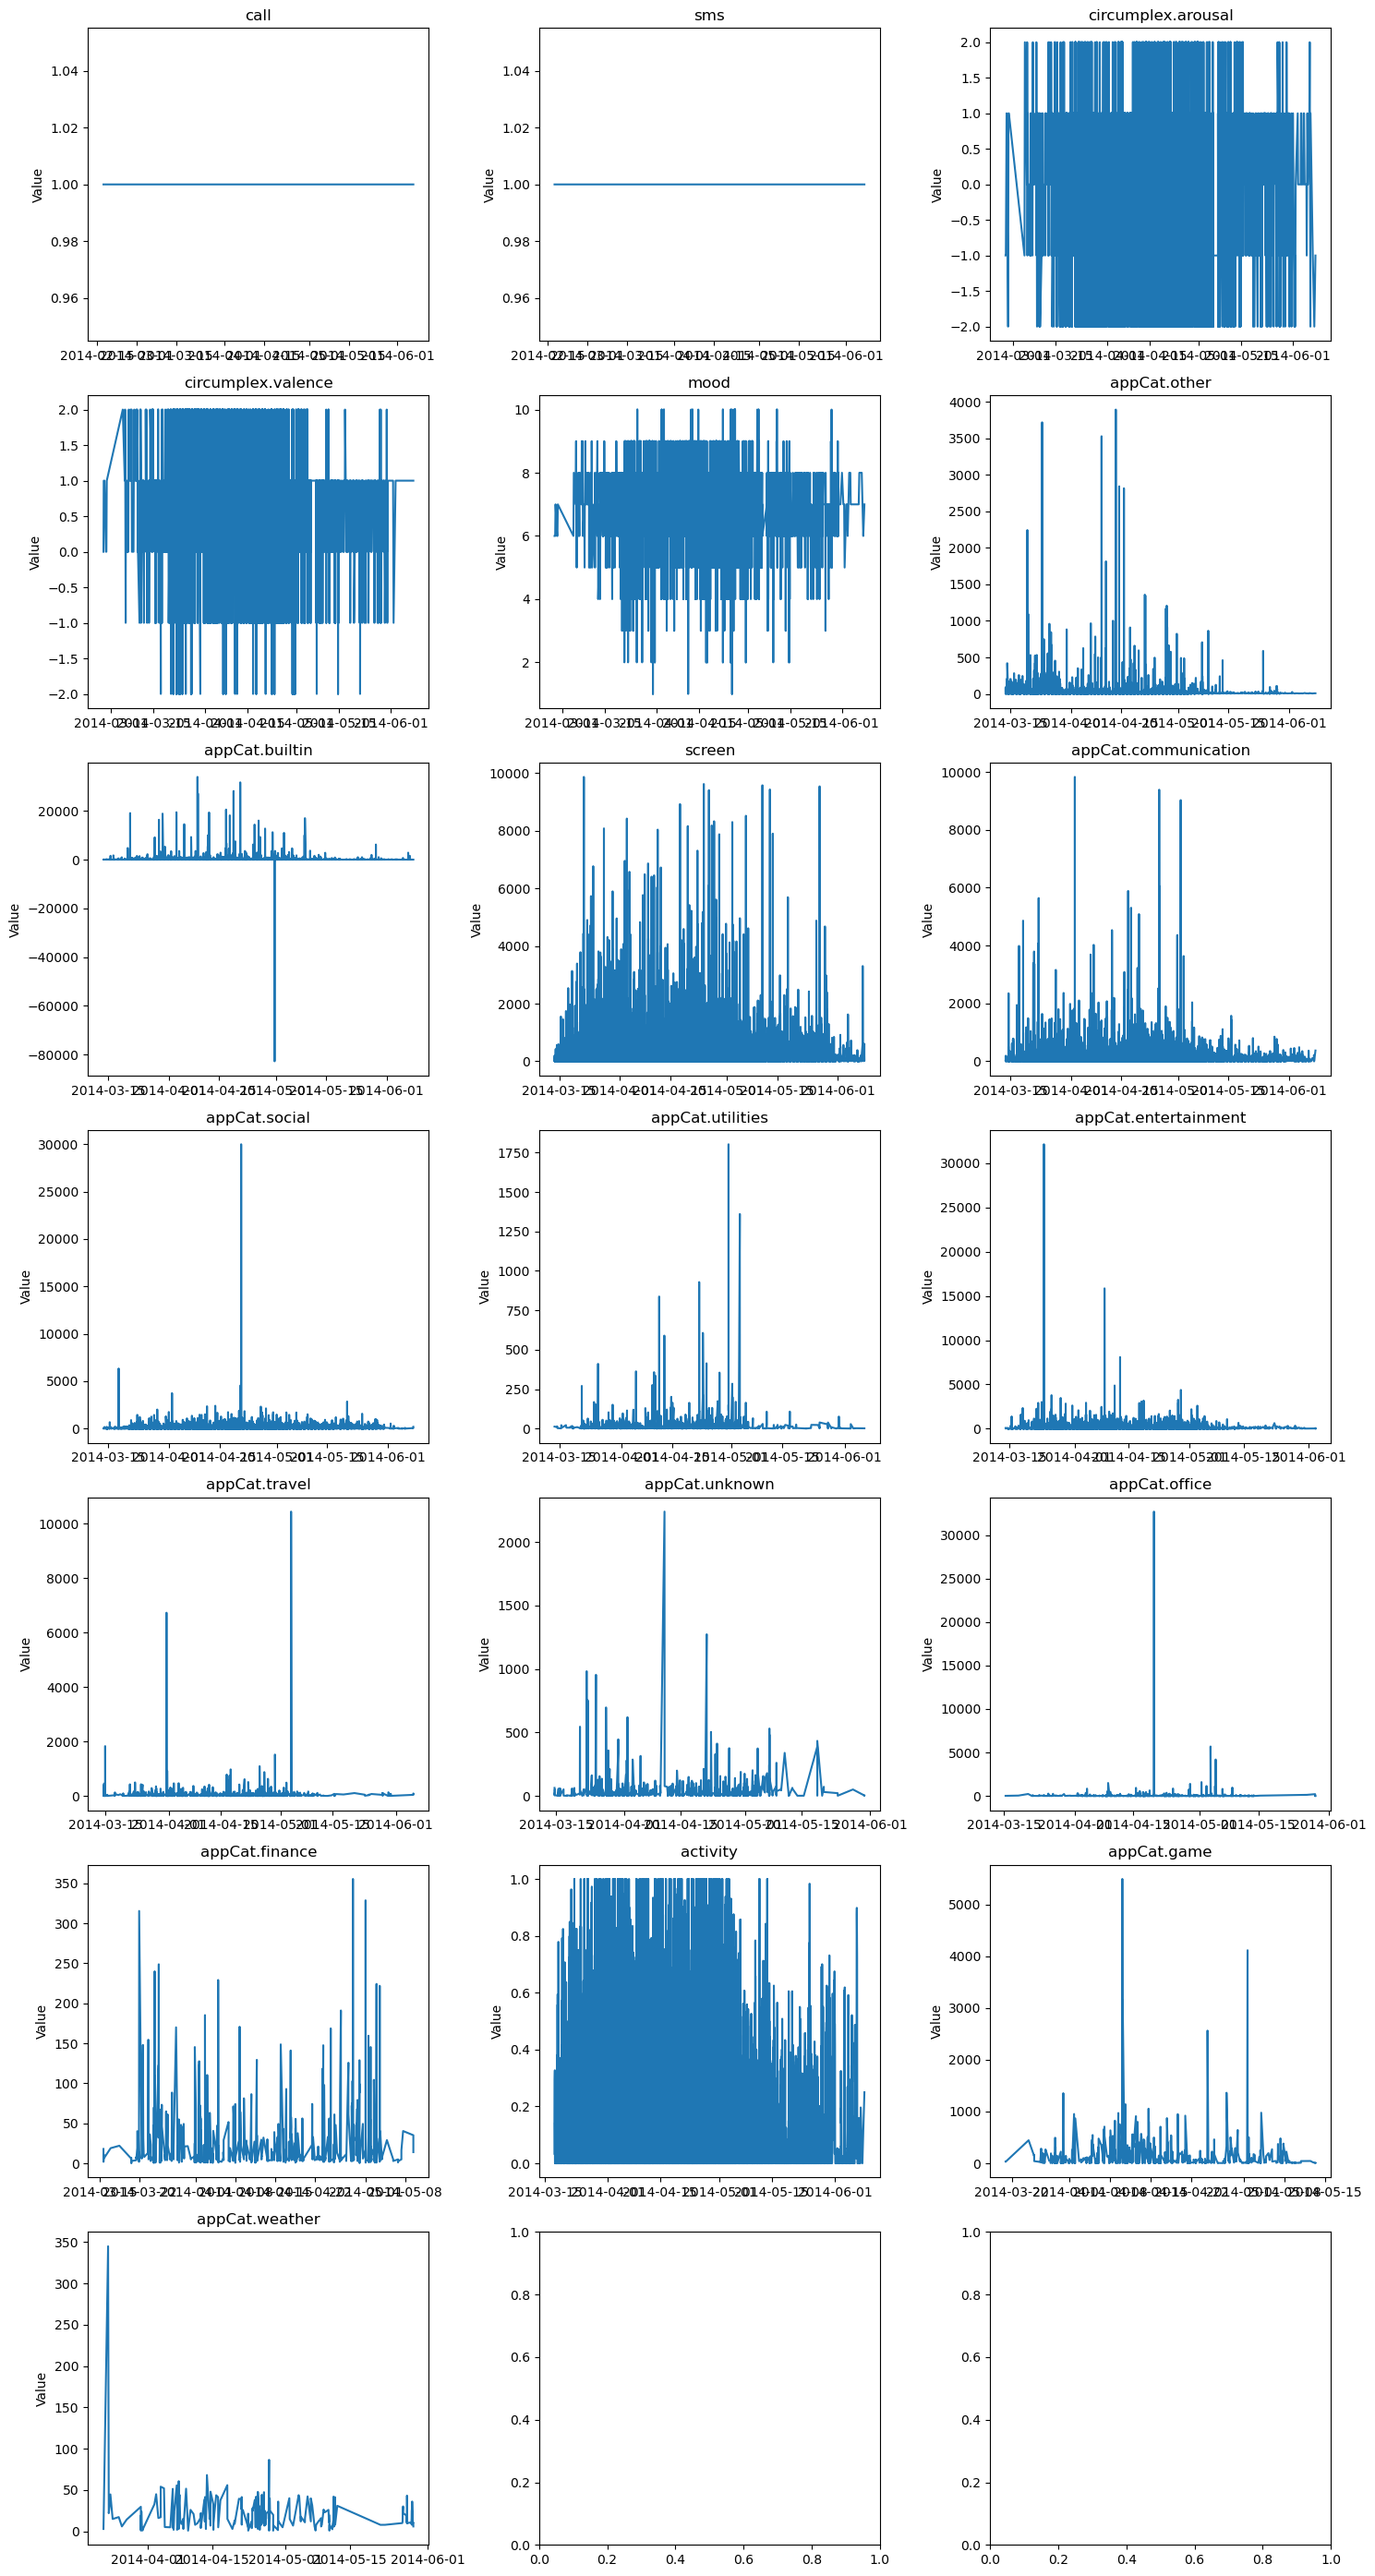

In [386]:
nvar = len(unique_variables)
ncol = 3
nrows = math.ceil(nvar/3)

fig, axs = plt.subplots(nrows, ncol, figsize=(15, 4 * nrows))
axs = axs.flatten()

for ax, var in zip(axs, unique_variables):
    subset = df[df["variable"] == var]
    
    ax.plot(subset["time"] ,subset["value"])
    ax.set_title(var)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

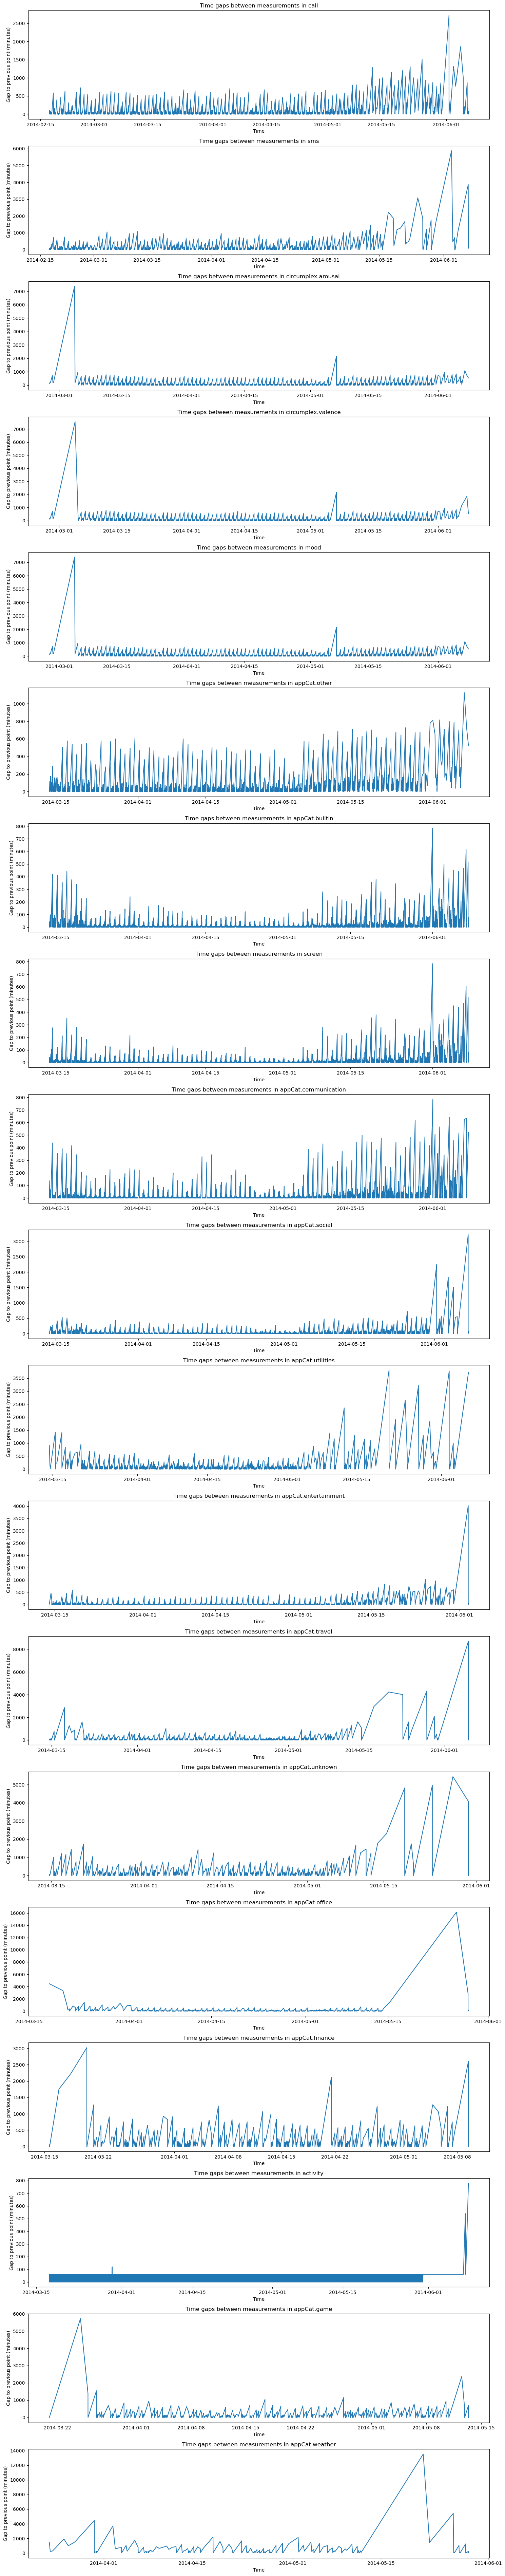

In [362]:
ncol = 1
nrows = math.ceil(len(unique_variables)/ncol)
expected = pd.Timedelta("1min")

fig, axs = plt.subplots(nrows, ncol, figsize=(15, 4 * nrows))
axs = axs.flatten()

for ax, var in zip(axs, unique_variables):
    subset = df[df["variable"] == var].copy()
    subset["gap"] = subset["time"].diff()

    # gaps = subset[subset["gap"] > expected].copy()
    # gaps["gap_start"] = gaps["time"] - gaps["gap"]
    # gaps["gap_end"] = gaps["time"]

    ax.plot(subset["time"], subset["gap"].dt.total_seconds() / 60)
    ax.set_xlabel("Time")
    ax.set_ylabel("Gap to previous point (minutes)")
    ax.set_title(f"Time gaps between measurements in {var}")

plt.tight_layout()
plt.show()

In [363]:
# expected = pd.Timedelta("1min")

# df['gap'] = df['time'].diff()
# gaps = df[df["gap"] > expected].copy()
# gaps["gap_start"] = gaps["time"] - gaps["gap"]
# gaps["gap_end"] = gaps["time"]

# plt.figure(figsize=(12, 4))
# plt.plot(df["time"], df["gap"].dt.total_seconds() / 60)
# plt.xlabel("Time")
# plt.ylabel("Gap to previous point (minutes)")
# plt.title("Time gaps between measurements")
# plt.show()

In [364]:
def clip_outliers(group):
    group = group.copy()  # important

    q1 = group["value"].quantile(0.25)
    q3 = group["value"].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    group["value"] = group["value"].clip(lower, upper)
    return group

df_clean = (
    df.groupby(["id", "variable"], group_keys=False)
      .apply(clip_outliers)
      .reset_index(drop=True)
)

print("Before:", len(df))
print("After :", len(df_clean))

Before: 376710
After : 376710


/var/folders/zd/749w5ygj74xc085l7fwx6kc00000gn/T/ipykernel_17747/3036311799.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(["id", "variable"], group_keys=False)


In [365]:
df_clean["time"] = pd.to_datetime(df_clean["time"])
df_clean["date"] = df_clean["time"].dt.floor("D")

sum_vars = [
    "screen",
    "call",
    "sms",
    "appCat.builtin",
    "appCat.communication",
    "appCat.entertainment",
    "appCat.finance",
    "appCat.game",
    "appCat.office",
    "appCat.other",
    "appCat.social",
    "appCat.travel",
    "appCat.unknown",
    "appCat.utilities",
    "appCat.weather",
]

mean_vars = [
    "circumplex.arousal",
    "circumplex.valence",
    "activity",
]


df_sum = (
    df_clean[df_clean["variable"].isin(sum_vars)]
    .groupby(["id", "date", "variable"])["value"]
    .sum()
    .reset_index()
)

df_mean = (
    df_clean[df_clean["variable"].isin(mean_vars)]
    .groupby(["id", "date", "variable"])["value"]
    .mean()
    .reset_index()
)

df_median = (
    df_clean[df_clean["variable"].isin(["mood"])]
    .groupby(["id", "date", "variable"])["value"]
    .median()
    .reset_index()
)

df_daily_long = pd.concat([df_sum, df_mean, df_median], ignore_index=True)

df_daily = (df_daily_long.pivot_table(index=["id", "date"],columns="variable",values="value").reset_index())

df_daily = df_daily.sort_values(["id", "date"]).copy()
df_daily["mood_next_day"] = df_daily.groupby("id")["mood"].shift(-1)

#maybe keep current mood
df_daily = df_daily.dropna(subset=["mood_next_day","mood"])

missing = df_daily.isna().mean().sort_values(ascending=False)
print(missing.head(20))

variable
appCat.weather          0.911257
appCat.game             0.849630
appCat.finance          0.832375
appCat.unknown          0.795399
appCat.office           0.781430
appCat.travel           0.666393
appCat.utilities        0.655711
sms                     0.654889
call                    0.405094
appCat.entertainment    0.342646
appCat.social           0.230074
appCat.other            0.119145
appCat.communication    0.084634
activity                0.084634
appCat.builtin          0.074774
screen                  0.069022
circumplex.valence      0.001643
mood                    0.000000
id                      0.000000
circumplex.arousal      0.000000
dtype: float64


In [366]:
df_daily = df_daily.loc[:, df_daily.isna().mean() < 0.7]

df_daily = df_daily.groupby("id").apply(
    lambda x: x.ffill().bfill()
).reset_index(drop=True)

df_daily = df_daily.fillna(df_daily.mean(numeric_only=True))

#Feature improvements 
feature_cols = df_daily.columns.difference(["id", "date", "mood_next_day"])

for lag in [1, 2, 3]:
    for col in feature_cols:
        df_daily[f"{col}_lag{lag}"] = df_daily.groupby("id")[col].shift(lag)

for col in feature_cols:
    df_daily[f"{col}_roll3"] = (
        df_daily.groupby("id")[col]
        .rolling(3)
        .mean()
        .reset_index(0, drop=True)
    )

for col in feature_cols:
    df_daily[f"{col}_norm"] = (
        df_daily[col] - df_daily.groupby("id")[col].transform("mean")
    )

df_daily = df_daily.dropna()

X = df_daily.drop(columns=["id", "date", "mood_next_day"])
y = df_daily["mood_next_day"]

/var/folders/zd/749w5ygj74xc085l7fwx6kc00000gn/T/ipykernel_17747/1913580007.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_daily = df_daily.groupby("id").apply(


In [367]:
split_date = df_daily["date"].quantile(0.8)

train = df_daily[df_daily["date"] <= split_date]
test = df_daily[df_daily["date"] > split_date]

X_train = train.drop(columns=["id", "date", "mood_next_day"])
y_train = train["mood_next_day"]

X_test = test.drop(columns=["id", "date", "mood_next_day"])
y_test = test["mood_next_day"]

def mood_to_class(x):
    if x <= 4:
        return "low"
    elif x <= 7:
        return "medium"
    else:
        return "high"

y_train_cls = y_train.apply(mood_to_class)
y_test_cls = y_test.apply(mood_to_class)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)


model.fit(X_train, y_train_cls)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test_cls, y_pred))
print(classification_report(y_test_cls, y_pred))

importances = pd.Series(model.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False).head(15))

Accuracy: 0.8105726872246696
              precision    recall  f1-score   support

        high       0.67      0.21      0.32        48
      medium       0.82      0.97      0.89       179

    accuracy                           0.81       227
   macro avg       0.74      0.59      0.60       227
weighted avg       0.79      0.81      0.77       227

variable
mood_roll3                    0.073145
mood_lag1                     0.050426
mood                          0.049074
mood_lag3                     0.025811
mood_lag2                     0.023663
appCat.other_lag2             0.019707
activity_roll3                0.018668
appCat.entertainment_roll3    0.018200
screen_roll3                  0.018014
appCat.entertainment_lag3     0.017952
circumplex.arousal_roll3      0.017386
screen_lag1                   0.017283
mood_norm                     0.016912
appCat.communication          0.015306
appCat.other_roll3            0.014087
dtype: float64


In [368]:
print(X_train.shape)
print(X_train.isna().sum().sum()) 
print(y_train_cls.value_counts())

(909, 84)
0
mood_next_day
medium    655
high      250
low         4
Name: count, dtype: int64
